# Hallazgos del análisis -- gráficos reales (no maquetas de UI)

`04_make_sketches.ipynb` produce **wireframes** de la UI D3.js planeada
(datos falsos/aleatorios, solo para mostrar el layout). Este notebook hace
lo opuesto: **gráficos reales calculados sobre nuestra data procesada de
verdad**, para respaldar los "hallazgos exploratorios iniciales" que pide la
Semana 6 y para chequear la hipótesis central de la propuesta antes de
comprometernos con ella en D3.

Nota: los títulos/etiquetas dentro de los gráficos quedan en inglés a
propósito, porque las imágenes PNG se insertan tal cual en `DataAnalysis.md`
(documento en inglés). El texto narrativo de este notebook sí está en
español.

Outputs guardados en `../analysis_plots/`. Correr después de `01`-`03`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

REPO_ROOT = Path.cwd().resolve().parents[2]  # deliveries/week06/code -> raíz del repo
PROCESSED_DIR = REPO_ROOT / "deliveries" / "week06" / "data" / "processed"
OUT_DIR = REPO_ROOT / "deliveries" / "week06" / "analysis_plots"
OUT_DIR.mkdir(parents=True, exist_ok=True)

elec = pd.read_csv(PROCESSED_DIR / "eeg_theta_per_electrode.csv")
elec_eo = elec[elec["task"] == "eyesopen"].copy()
roi_epochs = pd.read_csv(PROCESSED_DIR / "eeg_theta_epochs_roi.csv")
merged = pd.read_csv(PROCESSED_DIR / "merged_summary.csv")
paired_n = pd.read_csv(PROCESSED_DIR / "paired_n_summary.csv")

# Posiciones reales (x, y) de los electrodos -- mismo montaje en todas las grabaciones.
coords = pd.read_csv(
    REPO_ROOT / "ds004902" / "sub-01" / "ses-1" / "eeg" / "sub-01_ses-1_electrodes.tsv", sep="\t"
)[["name", "x", "y"]]

len(elec_eo), len(roi_epochs), len(merged)

(8479, 47733, 71)

## 1. n efectivo por marcador conductual (por qué cada vista debe mostrar su n)

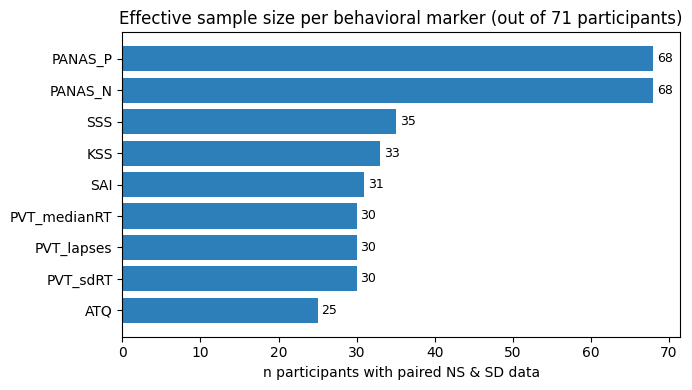

In [2]:
fig, ax = plt.subplots(figsize=(7, 4))
order = paired_n.sort_values("n_paired", ascending=True)
ax.barh(order["marker"], order["n_paired"], color="#2c7fb8")
ax.set_xlabel("n participants with paired NS & SD data")
ax.set_title("Effective sample size per behavioral marker (out of 71 participants)")
for y, v in enumerate(order["n_paired"]):
    ax.text(v + 0.5, y, str(v), va="center", fontsize=9)
fig.tight_layout()
fig.savefig(OUT_DIR / "01_paired_n_per_marker.png", dpi=150)
plt.show()

## 2. Topomap real: ¿dónde cambia de verdad la potencia/variabilidad theta? (Q1, Q2)

Diferencia pareada por electrodo (SD - NS), promediada sobre los 68 sujetos
con EEG eyes-open utilizable en ambas condiciones, marcando en rojo los
electrodos donde un t-test pareado da p < 0.05 (sin corregir --
exploratorio, no confirmatorio). Este es el análogo con datos reales de
`sketch_topomap_view.png`, e implementa directamente la idea de encoding
"diferencia + significancia" del paper de actividad aperiódica (ver
`../reviewed_papers/README.md`, #1).

In [3]:
def electrode_diff_stats(metric_col: str) -> pd.DataFrame:
    piv = elec_eo.pivot_table(index=["participant_id", "electrode"], columns="condition", values=metric_col).reset_index().dropna()
    rows = []
    for electrode, g in piv.groupby("electrode"):
        t, p = stats.ttest_rel(g["SD"], g["NS"])
        rows.append({"electrode": electrode, "mean_NS": g["NS"].mean(), "mean_SD": g["SD"].mean(),
                     "diff": g["SD"].mean() - g["NS"].mean(), "t": t, "p": p, "n": len(g)})
    return pd.DataFrame(rows).merge(coords, left_on="electrode", right_on="name")


power_stats = electrode_diff_stats("theta_mean")
var_stats = electrode_diff_stats("theta_std")
print(f"Potencia media: {(power_stats['p'] < 0.05).sum()}/{len(power_stats)} electrodos significativos (p<0.05, sin corregir)")
print(f"Variabilidad: {(var_stats['p'] < 0.05).sum()}/{len(var_stats)} electrodos significativos (p<0.05, sin corregir)")

Potencia media: 8/61 electrodos significativos (p<0.05, sin corregir)
Variabilidad: 4/61 electrodos significativos (p<0.05, sin corregir)


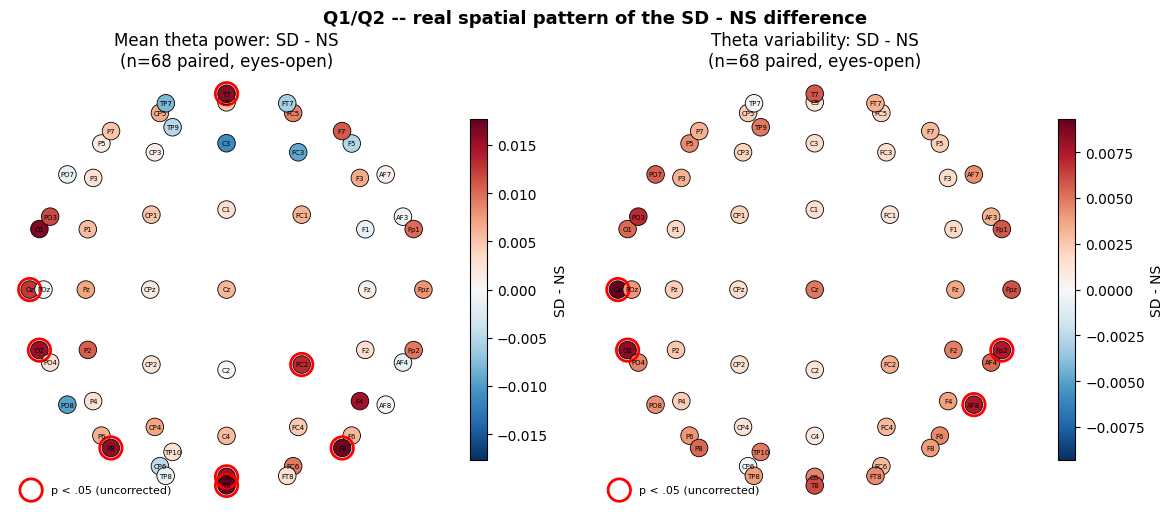

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

for ax, stats_df, title in zip(axes, [power_stats, var_stats], ["Mean theta power: SD - NS", "Theta variability: SD - NS"]):
    vmax = np.abs(stats_df["diff"]).max()
    sc = ax.scatter(stats_df["x"], stats_df["y"], c=stats_df["diff"], cmap="RdBu_r",
                     vmin=-vmax, vmax=vmax, s=160, edgecolors="black", linewidths=0.6)
    sig = stats_df[stats_df["p"] < 0.05]
    ax.scatter(sig["x"], sig["y"], facecolors="none", edgecolors="red", s=260, linewidths=2, label="p < .05 (uncorrected)")
    for _, row in stats_df.iterrows():
        ax.annotate(row["electrode"], (row["x"], row["y"]), fontsize=5, ha="center", va="center")
    ax.set_title(f"{title}\n(n=68 paired, eyes-open)")
    ax.set_aspect("equal")
    ax.axis("off")
    fig.colorbar(sc, ax=ax, shrink=0.7, label="SD - NS")
    ax.legend(loc="lower left", fontsize=8, frameon=False)

fig.suptitle("Q1/Q2 -- real spatial pattern of the SD - NS difference", fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(OUT_DIR / "02_topomap_real_diff_significance.png", dpi=150)
plt.show()

**Insight:** los electrodos significativos para potencia media (T8, C6, Oz,
T7, O2, P8, FC2, F8) son mayormente temporal/occipital/parietal, no la ROI
frontal/centro-temporal que la propuesta (siguiendo a Cui et al. 2026)
esperaba como protagonista -- y hay *menos* electrodos significativos para
variabilidad (4) que para potencia media (8), justo lo opuesto de lo que
predecía la premisa de la propuesta. Leer con cautela (n=68, sin corregir,
pipeline de primera pasada -- ver limitaciones en `DataAnalysis.md`), pero
es exactamente el tipo de hallazgo que un topomap interactivo debería dejar
descubrir directamente al lector, en vez de un resumen de texto que se lo
imponga.

## 3. Comparación NS vs SD a nivel de grupo, por ROI (pareado, n=68)

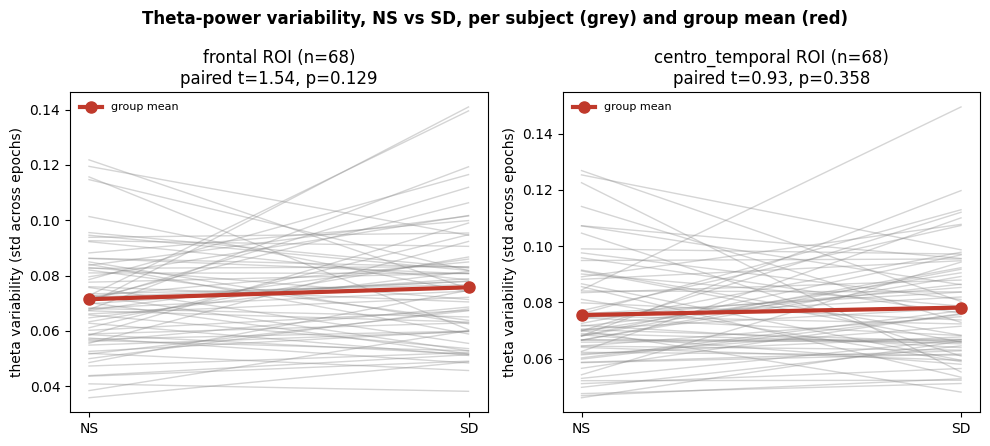

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
for ax, roi in zip(axes, ["frontal", "centro_temporal"]):
    sub = merged.dropna(subset=[f"{roi}_theta_variability_NS", f"{roi}_theta_variability_SD"])
    for _, row in sub.iterrows():
        ax.plot(["NS", "SD"], [row[f"{roi}_theta_variability_NS"], row[f"{roi}_theta_variability_SD"]],
                color="#888888", alpha=0.35, linewidth=1)
    means = [sub[f"{roi}_theta_variability_NS"].mean(), sub[f"{roi}_theta_variability_SD"].mean()]
    ax.plot(["NS", "SD"], means, color="#c0392b", linewidth=3, marker="o", markersize=8, label="group mean")
    t, p = stats.ttest_rel(sub[f"{roi}_theta_variability_SD"], sub[f"{roi}_theta_variability_NS"])
    ax.set_title(f"{roi} ROI (n={len(sub)})\npaired t={t:.2f}, p={p:.3f}")
    ax.set_ylabel("theta variability (std across epochs)")
    ax.legend(fontsize=8, frameon=False)
fig.suptitle("Theta-power variability, NS vs SD, per subject (grey) and group mean (red)", fontsize=12, fontweight="bold")
fig.tight_layout()
fig.savefig(OUT_DIR / "03_ns_vs_sd_variability_paired.png", dpi=150)
plt.show()

**Insight:** la dispersión de las líneas grises individuales es mucho más
ancha que el corrimiento de la línea roja del promedio de grupo -- algunos
sujetos muestran un aumento fuerte de SD sobre NS, otros muestran una
disminución. Esta es la versión visual del resultado nulo a nivel de grupo
de la Sección 4 de `DataAnalysis.md`, y es la justificación directa de toda
la premisa del proyecto: un solo gráfico de promedio de grupo esconde esta
variación individual, que es exactamente lo que el scatter con linked
brushing (Vista 3) busca exponer.

## 4. Scatter de vulnerabilidad con datos reales (Q3) -- delta variabilidad theta vs delta PVT

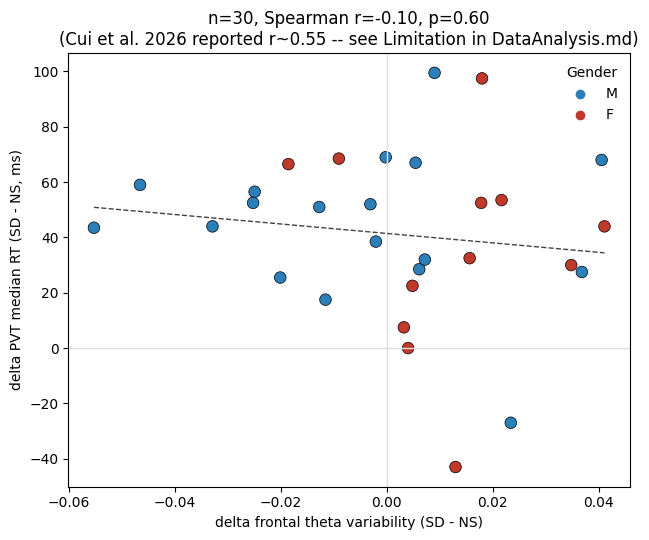

In [6]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
sub = merged.dropna(subset=["delta_frontal_theta_variability", "delta_PVT_medianRT"])
ax.axhline(0, color="#dddddd", linewidth=1)
ax.axvline(0, color="#dddddd", linewidth=1)
colors = sub["Gender"].map({"M": "#2c7fb8", "F": "#c0392b"})
ax.scatter(sub["delta_frontal_theta_variability"], sub["delta_PVT_medianRT"], c=colors, s=70, edgecolors="black", linewidths=0.5)

r, p = stats.spearmanr(sub["delta_frontal_theta_variability"], sub["delta_PVT_medianRT"])
z = np.polyfit(sub["delta_frontal_theta_variability"], sub["delta_PVT_medianRT"], 1)
xs = np.linspace(sub["delta_frontal_theta_variability"].min(), sub["delta_frontal_theta_variability"].max(), 50)
ax.plot(xs, np.polyval(z, xs), color="#444444", linestyle="--", linewidth=1)

ax.set_xlabel("delta frontal theta variability (SD - NS)")
ax.set_ylabel("delta PVT median RT (SD - NS, ms)")
ax.set_title(f"n={len(sub)}, Spearman r={r:.2f}, p={p:.2f}\n(Cui et al. 2026 reported r~0.55 -- see Limitation in DataAnalysis.md)")
ax.scatter([], [], c="#2c7fb8", label="M"); ax.scatter([], [], c="#c0392b", label="F")
ax.legend(frameon=False, title="Gender")
fig.tight_layout()
fig.savefig(OUT_DIR / "04_vulnerability_scatter_real.png", dpi=150)
plt.show()

## 5. Dinámica intra-grabación real (Q6) -- sujeto más vulnerable vs más resistente

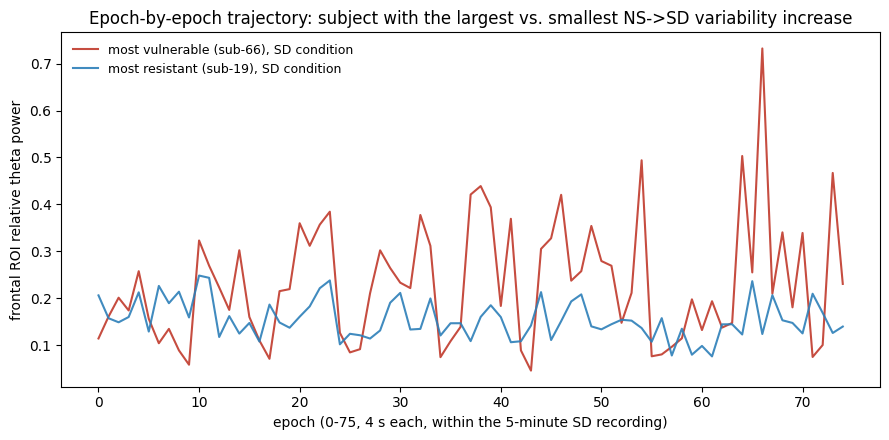

In [7]:
ranked = merged.dropna(subset=["delta_frontal_theta_variability"]).sort_values("delta_frontal_theta_variability")
most_resistant = ranked.iloc[0]["participant_id"]   # delta más negativo (la variabilidad bajó con SD)
most_vulnerable = ranked.iloc[-1]["participant_id"]  # delta más positivo (la variabilidad subió más con SD)

fig, ax = plt.subplots(figsize=(9, 4.5))
for pid, label, color in [(most_vulnerable, "most vulnerable", "#c0392b"), (most_resistant, "most resistant", "#2c7fb8")]:
    sub = roi_epochs[(roi_epochs["participant_id"] == pid) & (roi_epochs["condition"] == "SD") &
                      (roi_epochs["task"] == "eyesopen") & (roi_epochs["roi"] == "frontal")].sort_values("epoch_idx")
    if len(sub):
        ax.plot(sub["epoch_idx"], sub["theta_power"], color=color, alpha=0.9, linewidth=1.5,
                label=f"{label} ({pid}), SD condition")

ax.set_xlabel("epoch (0-75, 4 s each, within the 5-minute SD recording)")
ax.set_ylabel("frontal ROI relative theta power")
ax.set_title("Epoch-by-epoch trajectory: subject with the largest vs. smallest NS->SD variability increase")
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig(OUT_DIR / "05_temporal_dynamics_real.png", dpi=150)
plt.show()

**Insight:** elegir a los dos sujetos en los extremos de
`delta_frontal_theta_variability` y graficar su serie real de épocas dentro
de la grabación (en vez de las curvas suaves falsas del wireframe) es un
buen chequeo de sanidad: muestra si la "variabilidad" tal como la calculamos
(std entre 75 épocas) se ve como una fluctuación genuina época a época o
está dominada por unas pocas épocas/artefactos atípicos que sobrevivieron a
la heurística simple de canales malos. Vale la pena revisar por sujeto antes
de la Semana 10 si alguna trayectoria se ve implausiblemente picuda.